# Releasing a whole table: `release_query` and `link_sum`

[`opendp_noisyvalue.ipynb`](opendp_noisyvalue.ipynb) wraps a single scalar release. Real releases are rarely one scalar, though — the usual OpenDP workflow is a `dp.Context` query against a whole table, which noises many cells at once (one per group). This notebook is about the two pieces of `noisyvalue.opendp` built for that layer:

- **`release_query`** turns one `Context` query's release into a tidy frame of noisy values. It reads each noised column's mechanism and scale off the query itself — the same thing `query.summarize()` reports — so nothing has to be tracked by hand.
- **`link_sum`** folds a *finer* release's group sums into a *coarser* release of the same aggregate over the same data (say, counts by region into the grand total). The finer cells already sum to the true coarse value, so their sum is a second, independent estimate of it — folding it in tightens the coarse posterior in closed form, for free, no extra privacy budget spent.

In [1]:
import numpy as np
import polars as pl
import matplotlib.pyplot as plt

import opendp.prelude as dp

dp.enable_features("contrib", "honest-but-curious")

from noisyvalue import opendp as nvdp
from noisyvalue import plot_posterior

## The data

A survey of 120 respondents, each recording which of three regions they live in. We'll release two things from it: counts broken down by region, and the grand total number of respondents.

In [2]:
region = ["a"] * 40 + ["b"] * 58 + ["c"] * 22
data = pl.LazyFrame({"region": region})

true_counts = {r: region.count(r) for r in "abc"}
true_total = len(region)
print(f"true counts: {true_counts}, true total: {true_total}")

true counts: {'a': 40, 'b': 58, 'c': 22}, true total: 120


## A `Context` for two releases

The region-level release needs a margin declaring that all three regions always appear in the output (`invariant="keys"` — otherwise a group with a small true count could be dropped by thresholding, which `link_sum` assumes never happens). The grand-total release groups by nothing, so it gets its own margin with `by=[]`. `split_evenly_over=2` reserves budget for exactly the two releases this notebook makes.

In [3]:
ctx = dp.Context.compositor(
    data=data,
    privacy_unit=dp.unit_of(contributions=1),
    privacy_loss=dp.loss_of(rho=0.5),
    split_evenly_over=2,
    margins=[
        dp.polars.Margin(by=["region"], invariant="keys",
                         max_length=200, max_groups=3),
        dp.polars.Margin(by=[], max_length=200, max_groups=1),
    ])

## What a query already knows about itself

`query.summarize()` is free to call — it reports the plan's noise parameters without spending any budget or touching the data. For every noised column it gives the aggregate, the noise distribution, and the scale:

In [4]:
preview = ctx.query().group_by("region").agg(pl.len().dp.noise())
preview.summarize()

column,aggregate,distribution,scale
str,str,str,f64
"""len""","""Frame Length""","""Integer Gaussian""",1.414214


That's exactly the metadata a posterior needs — distribution family and scale — and it's sitting right there on the query. Calling `.release().collect()` instead spends the budget and hands back a bare polars frame: a plain integer in each cell, with nothing left to say which mechanism produced it or how far it might be from the truth. For one query you could copy `summarize()`'s numbers by hand; for a released frame with several noised columns, or many releases over a session, tracking which scale goes with which column becomes exactly the bookkeeping `opendp_basics.ipynb` ran into for a single number, multiplied out.

## `release_query`: read the metadata, do the wrapping

`release_query` runs a query's own `release().collect()` (spending its budget once) and wraps every noised cell using the mechanism and scale `summarize()` already reported — no need to say which distribution or scale to expect. Group-by columns pass through as plain data; noised columns come back as `NoisyIntArray`/`NoisyFloatArray` columns of a tidy pandas frame. Passing a `registry` gives each cell a stable identity — `(namespace, column, group key)` — which is what lets `link_sum` find matching cells across two releases.

In [5]:
registry = nvdp.SharedLatentRegistry()

fine = nvdp.release_query(
    ctx.query().group_by("region").agg(pl.len().dp.noise()),
    registry=registry)
fine.frame

,region,len
0,c,~21
1,a,~40
2,b,~58


In [6]:
coarse = nvdp.release_query(
    ctx.query().select(pl.len().dp.noise()),
    registry=registry)
coarse.frame

,len
0,~121


## Two independent looks at the same total

`coarse.frame`'s single cell is a noisy view of `true_total`, built from its own release noise alone. But `fine`'s three regional counts sum to that same true total — a second, independent measurement of it, paid for out of a different share of the budget. Right now nothing connects the two; the coarse posterior is only as precise as its own release:

before link_sum: center=121.00, variance=2.000


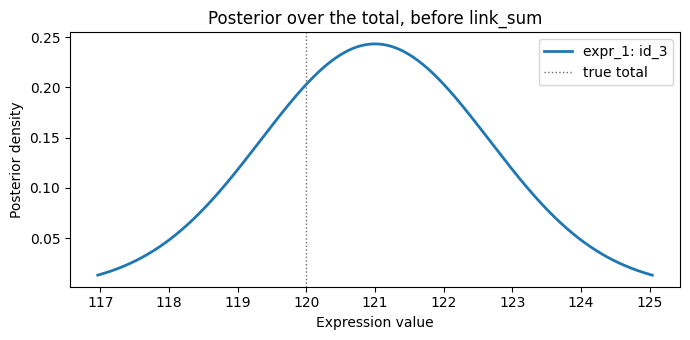

In [7]:
total = coarse.frame["len"].iloc[0]
total_key = coarse._cell_keys["len"][0]
center_before, variance_before = registry.posterior(total_key)
print(f"before link_sum: center={center_before:.2f}, variance={variance_before:.3f}")

fig, ax = plt.subplots(figsize=(7, 3.5))
plot_posterior(total, ax=ax)
ax.axvline(true_total, color="#6b6b6b", linewidth=1, linestyle=":",
           label="true total")
ax.legend()
ax.set_title("Posterior over the total, before link_sum")
plt.tight_layout()

## `link_sum` folds the fine release in

`link_sum` sums `fine`'s per-region centres and variances into one independent estimate of the grand total, then combines it with `coarse`'s own posterior in closed form — the same precision-weighted rule `SharedLatentRegistry` uses to combine two repeated measurements of one key, just applied across a hierarchy of releases instead of a single repeated one. `total` is a live view of the registry's node, so it tightens in place even though it was issued *before* the link:

In [8]:
nvdp.link_sum(fine, coarse)

after link_sum:  center=120.50, variance=1.500
variance shrank by 25%, at no extra privacy cost


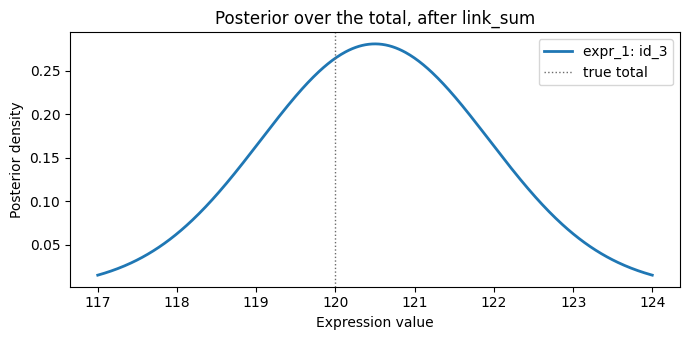

In [9]:
center_after, variance_after = registry.posterior(total_key)
print(f"after link_sum:  center={center_after:.2f}, variance={variance_after:.3f}")
print(f"variance shrank by {100 * (1 - variance_after / variance_before):.0f}%, at no extra privacy cost")

fig, ax = plt.subplots(figsize=(7, 3.5))
plot_posterior(total, ax=ax)
ax.axvline(true_total, color="#6b6b6b", linewidth=1, linestyle=":",
           label="true total")
ax.legend()
ax.set_title("Posterior over the total, after link_sum")
plt.tight_layout()

`total` — the same object plotted above, sampled and printed before any of this ran — reflects the fold automatically, because it never held a snapshot of the posterior, only a view of the shared node.

## The fold can't be double-counted

`link_sum` remembers which `(fine, coarse)` pairs it has already folded, so accidentally calling it twice — which would count the same evidence for the total twice and make the posterior *too* confident — is refused rather than silently corrupting the estimate:

In [10]:
try:
    nvdp.link_sum(fine, coarse)
except ValueError as e:
    print(f"refused: {e}")

refused: The sum of [('7f6412b1a283ce46', 'len', (('region', 'c'),)), ('7f6412b1a283ce46', 'len', (('region', 'a'),)), ('7f6412b1a283ce46', 'len', (('region', 'b'),))] was already folded into ('ac99d9b6cea35fda', 'len', ()); folding the same evidence twice would double-count it


## Why these exist

`release_query` exists because a `Context` query is already the source of truth for its own noise — mechanism, scale, which columns were noised at all — so wrapping the release by hand would just be re-typing what `summarize()` already reports, once per column, for every query made. `link_sum` exists because a single private dataset is usually released at more than one level of granularity (per-region counts *and* a grand total, here; in `src/census.py`'s hierarchy of geographies, dozens of levels), and those releases are not actually independent facts about the world — the finer numbers really do sum to the coarser one. Treating them as unrelated wastes information you already paid privacy budget for; `link_sum` is the closed-form way to spend that information instead, without re-deriving the combination rule by hand each time.